# Assignment 2: Data Acquisition and Preprocessing
# Project Title: Predicting Survival Outcomes Among Lung Cancer Patients Using Machine Learning: An Analysis of Demographic and Clinical Factors
## Objective: 
The objective of this project is to prepare a lung cancer patient dataset for machine learning models that will predict the survival outcome of an individual patient. The prediction task classifies patients into two survival categories: short-term survival and long-term survival.

The dataset contains demographic, clinical, treatment, comorbidity, and laboratory-related variables. The preprocessing process includes assessing data quality, examining summary statistics, identifying missing values and outliers, cleaning the data, encoding categorical variables, and scaling numerical features. 

The final cleaned dataset will be used in the subsequent modeling stage of the capstone project.

In [1]:
#Import the Python Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_style("whitegrid")

In [2]:
print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
#Load the Dataset

df = pd.read_csv("../Data/lung_cancer_data.csv")
print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,Patient_ID,Age,Gender,Smoking_History,Tumor_Size_mm,Tumor_Location,Stage,Treatment,Survival_Months,Ethnicity,Insurance_Type,Family_History,Comorbidity_Diabetes,Comorbidity_Hypertension,Comorbidity_Heart_Disease,Comorbidity_Chronic_Lung_Disease,Comorbidity_Kidney_Disease,Comorbidity_Autoimmune_Disease,Comorbidity_Other,Performance_Status,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Blood_Pressure_Pulse,Hemoglobin_Level,White_Blood_Cell_Count,Platelet_Count,Albumin_Level,Alkaline_Phosphatase_Level,Alanine_Aminotransferase_Level,Aspartate_Aminotransferase_Level,Creatinine_Level,LDH_Level,Calcium_Level,Phosphorus_Level,Glucose_Level,Potassium_Level,Sodium_Level,Smoking_Pack_Years
0,Patient0000,68,Male,Current Smoker,81.678677,Lower Lobe,Stage III,Surgery,44,Hispanic,Medicare,No,Yes,Yes,Yes,No,Yes,Yes,Yes,3,161,99,92,13.538000,9.800707,321.735266,3.568383,49.310048,27.985571,46.801214,1.245849,239.240255,10.366307,3.547734,113.919243,4.968163,139.822861,17.006956
1,Patient0001,58,Male,Never Smoked,78.448272,Lower Lobe,Stage I,Radiation Therapy,101,Caucasian,Private,Yes,Yes,Yes,No,No,Yes,Yes,No,4,101,91,93,16.800312,4.378428,251.581538,3.699357,111.421632,30.120956,39.711531,1.463231,233.515237,10.081731,2.945020,101.321578,3.896795,135.449361,93.270893
2,Patient0002,44,Male,Former Smoker,67.714305,Lower Lobe,Stage I,Chemotherapy,69,African American,Other,Yes,No,No,No,Yes,Yes,No,No,0,109,74,81,14.473493,6.157792,393.456532,4.708385,76.648006,5.882418,32.640602,0.630109,169.037460,8.660892,4.637399,78.214177,4.369050,143.377155,70.348376
3,Patient0003,72,Male,Current Smoker,70.806008,Lower Lobe,Stage III,Chemotherapy,95,African American,Medicare,Yes,Yes,No,Yes,No,Yes,Yes,No,1,103,85,68,17.442063,6.259383,275.177898,4.727672,81.952486,38.908154,44.319393,0.594342,213.967590,8.832669,3.617098,127.895361,4.348474,138.586005,19.828128
4,Patient0004,37,Female,Never Smoked,87.272433,Lower Lobe,Stage IV,Radiation Therapy,105,Asian,Medicaid,No,Yes,Yes,Yes,No,Yes,No,No,0,165,69,99,13.545171,5.203516,381.705572,4.605604,107.513423,26.344877,15.746906,1.478239,118.187543,9.247609,4.773255,148.801185,3.671976,141.230724,81.047456


In [4]:
print("Dataset shape:", df.shape)

df.info()

Dataset shape: (23658, 38)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23658 entries, 0 to 23657
Data columns (total 38 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        23658 non-null  object 
 1   Age                               23658 non-null  int64  
 2   Gender                            23658 non-null  object 
 3   Smoking_History                   23658 non-null  object 
 4   Tumor_Size_mm                     23658 non-null  float64
 5   Tumor_Location                    23658 non-null  object 
 6   Stage                             23658 non-null  object 
 7   Treatment                         23658 non-null  object 
 8   Survival_Months                   23658 non-null  int64  
 9   Ethnicity                         23658 non-null  object 
 10  Insurance_Type                    23658 non-null  object 
 11  Family_History                    23658 

# 1. Dataset source and description: 
The dataset used in this project was obtained from Kaggle and is titled Lung Cancer Prediction, uploaded by Rashad Mammadov. The dataset contains patient-level demographic, clinical, treatment, comorbidity, laboratory, and survival-related information.

The downloaded dataset contains **23,658 patient records** and **38 variables**. The variables include demographic characteristics such as age,gender, and ethnicity; clinical characteristics such as tumor size, cancer stage, and performance status; treatment information; comorbidity indicators; laboratory measurements; and survival duration measured in months.

The original dataset contains `Survival_Months`, which records the patient's survival duration.  For this project, this continuous measure was converted into the binary target variable used for the capstone analysis. A five-year (60-month) cutoff was applied: patients who survived fewer than 60 months were classified as short-term survivors, while those who survived 60 months or longer were classified as long-term survivors.

After applying this classification, the resulting target variable contains 11,710 short-term survival cases and 11,948 long-term survival cases.

In [5]:
# Initial Data Inspection
print("Number of rows:", df.shape[0])

Number of rows: 23658


In [6]:
print("Number of columns:", df.shape[1])

Number of columns: 38


In [7]:
df.columns.tolist()

['Patient_ID',
 'Age',
 'Gender',
 'Smoking_History',
 'Tumor_Size_mm',
 'Tumor_Location',
 'Stage',
 'Treatment',
 'Survival_Months',
 'Ethnicity',
 'Insurance_Type',
 'Family_History',
 'Comorbidity_Diabetes',
 'Comorbidity_Hypertension',
 'Comorbidity_Heart_Disease',
 'Comorbidity_Chronic_Lung_Disease',
 'Comorbidity_Kidney_Disease',
 'Comorbidity_Autoimmune_Disease',
 'Comorbidity_Other',
 'Performance_Status',
 'Blood_Pressure_Systolic',
 'Blood_Pressure_Diastolic',
 'Blood_Pressure_Pulse',
 'Hemoglobin_Level',
 'White_Blood_Cell_Count',
 'Platelet_Count',
 'Albumin_Level',
 'Alkaline_Phosphatase_Level',
 'Alanine_Aminotransferase_Level',
 'Aspartate_Aminotransferase_Level',
 'Creatinine_Level',
 'LDH_Level',
 'Calcium_Level',
 'Phosphorus_Level',
 'Glucose_Level',
 'Potassium_Level',
 'Sodium_Level',
 'Smoking_Pack_Years']

In [8]:
df.dtypes

Patient_ID                           object
Age                                   int64
Gender                               object
Smoking_History                      object
Tumor_Size_mm                       float64
Tumor_Location                       object
Stage                                object
Treatment                            object
Survival_Months                       int64
Ethnicity                            object
Insurance_Type                       object
Family_History                       object
Comorbidity_Diabetes                 object
Comorbidity_Hypertension             object
Comorbidity_Heart_Disease            object
Comorbidity_Chronic_Lung_Disease     object
Comorbidity_Kidney_Disease           object
Comorbidity_Autoimmune_Disease       object
Comorbidity_Other                    object
Performance_Status                    int64
Blood_Pressure_Systolic               int64
Blood_Pressure_Diastolic              int64
Blood_Pressure_Pulse            

In [9]:
df.describe()

,Age,Tumor_Size_mm,Survival_Months,Performance_Status,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Blood_Pressure_Pulse,Hemoglobin_Level,White_Blood_Cell_Count,Platelet_Count,Albumin_Level,Alkaline_Phosphatase_Level,Alanine_Aminotransferase_Level,Aspartate_Aminotransferase_Level,Creatinine_Level,LDH_Level,Calcium_Level,Phosphorus_Level,Glucose_Level,Potassium_Level,Sodium_Level,Smoking_Pack_Years
count,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000,23658.000000
mean,54.439344,55.383736,59.863809,1.999915,134.462381,84.475780,79.585299,14.000137,6.735637,299.867482,3.998981,75.027604,22.504677,30.133226,0.999459,174.734575,9.261114,3.742771,109.895553,4.245646,140.028215,49.913594
std,14.396386,26.004354,34.246042,1.413675,26.020492,14.409826,11.546690,2.301411,1.879292,86.897568,0.576931,25.936175,10.047864,11.560915,0.287517,43.230997,0.719875,0.721708,23.109136,0.431968,2.894568,28.870940
min,30.000000,10.004279,1.000000,0.000000,90.000000,60.000000,60.000000,10.000070,3.501213,150.017892,3.000080,30.007235,5.001090,10.000860,0.500001,100.002721,8.000018,2.500069,70.000420,3.500034,135.000934,0.016800
25%,42.000000,32.972797,30.000000,1.000000,112.000000,72.000000,70.000000,11.990625,5.108723,224.884576,3.504579,52.624860,13.816180,20.065339,0.748845,137.444977,8.640877,3.120107,89.828616,3.871842,137.540078,25.026793
50%,54.000000,55.296297,60.000000,2.000000,134.000000,85.000000,80.000000,13.983383,6.729774,299.933443,3.999931,75.089745,22.547943,30.271772,1.001183,174.390634,9.259304,3.730837,109.949488,4.242236,140.002209,49.926220
75%,67.000000,78.190014,89.000000,3.000000,157.000000,97.000000,90.000000,15.999260,8.353701,375.437029,4.499102,97.453941,31.092935,40.107488,1.249173,212.228273,9.883248,4.364422,130.061977,4.618318,142.541883,74.924580
max,79.000000,99.990554,119.000000,4.000000,179.000000,109.000000,99.000000,17.999957,9.999535,449.974734,4.999968,119.994705,39.999543,49.998571,1.499998,249.996391,10.499913,4.999974,149.997056,4.999954,144.999869,99.999493


# 2. Data quality assessment

In [10]:
# Check duplicates:
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [11]:
# Check duplicate patient IDs:
duplicate_ids = df["Patient_ID"].duplicated().sum()

print("Duplicate Patient IDs:", duplicate_ids)

Duplicate Patient IDs: 0


In [12]:
# check categorical variables:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


Patient_ID
Patient_ID
Patient0000     1
Patient15768    1
Patient15777    1
Patient15776    1
Patient15775    1
               ..
Patient7884     1
Patient7883     1
Patient7882     1
Patient7881     1
Patient23657    1
Name: count, Length: 23658, dtype: int64

Gender
Gender
Male      11924
Female    11734
Name: count, dtype: int64

Smoking_History
Smoking_History
Former Smoker     7998
Current Smoker    7845
Never Smoked      7815
Name: count, dtype: int64

Tumor_Location
Tumor_Location
Upper Lobe     7928
Middle Lobe    7910
Lower Lobe     7820
Name: count, dtype: int64

Stage
Stage
Stage IV     6011
Stage III    5922
Stage I      5905
Stage II     5820
Name: count, dtype: int64

Treatment
Treatment
Radiation Therapy    5966
Surgery              5944
Chemotherapy         5936
Targeted Therapy     5812
Name: count, dtype: int64

Ethnicity
Ethnicity
Caucasian           4765
Hispanic            4761
African American    4737
Asian               4734
Other               4661
Name: count,

# 3. Summary statistics


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,23658.0,54.439344,14.396386,30.000000,42.000000,54.000000,67.000000,79.000000
Tumor_Size_mm,23658.0,55.383736,26.004354,10.004279,32.972797,55.296297,78.190014,99.990554
Survival_Months,23658.0,59.863809,34.246042,1.000000,30.000000,60.000000,89.000000,119.000000
Performance_Status,23658.0,1.999915,1.413675,0.000000,1.000000,2.000000,3.000000,4.000000
Blood_Pressure_Systolic,23658.0,134.462381,26.020492,90.000000,112.000000,134.000000,157.000000,179.000000
Blood_Pressure_Diastolic,23658.0,84.475780,14.409826,60.000000,72.000000,85.000000,97.000000,109.000000
Blood_Pressure_Pulse,23658.0,79.585299,11.546690,60.000000,70.000000,80.000000,90.000000,99.000000
Hemoglobin_Level,23658.0,14.000137,2.301411,10.000070,11.990625,13.983383,15.999260,17.999957
White_Blood_Cell_Count,23658.0,6.735637,1.879292,3.501213,5.108723,6.729774,8.353701,9.999535
Platelet_Count,23658.0,299.867482,86.897568,150.017892,224.884576,299.933443,375.437029,449.974734


In [14]:
# Numerical-only summary
numeric_columns = df.select_dtypes(include=np.number).columns
summary_statistics = df[numeric_columns].describe().T
summary_statistics


,count,mean,std,min,25%,50%,75%,max
Age,23658.0,54.439344,14.396386,30.000000,42.000000,54.000000,67.000000,79.000000
Tumor_Size_mm,23658.0,55.383736,26.004354,10.004279,32.972797,55.296297,78.190014,99.990554
Survival_Months,23658.0,59.863809,34.246042,1.000000,30.000000,60.000000,89.000000,119.000000
Performance_Status,23658.0,1.999915,1.413675,0.000000,1.000000,2.000000,3.000000,4.000000
Blood_Pressure_Systolic,23658.0,134.462381,26.020492,90.000000,112.000000,134.000000,157.000000,179.000000
Blood_Pressure_Diastolic,23658.0,84.475780,14.409826,60.000000,72.000000,85.000000,97.000000,109.000000
Blood_Pressure_Pulse,23658.0,79.585299,11.546690,60.000000,70.000000,80.000000,90.000000,99.000000
Hemoglobin_Level,23658.0,14.000137,2.301411,10.000070,11.990625,13.983383,15.999260,17.999957
White_Blood_Cell_Count,23658.0,6.735637,1.879292,3.501213,5.108723,6.729774,8.353701,9.999535
Platelet_Count,23658.0,299.867482,86.897568,150.017892,224.884576,299.933443,375.437029,449.974734


# 4. Missing value analysis

In [15]:
missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": missing_percentage
})

missing_table.sort_values(
    by="Missing_Count",
    ascending=False
)

,Missing_Count,Missing_Percentage
Patient_ID,0,0.0
Alanine_Aminotransferase_Level,0,0.0
Blood_Pressure_Diastolic,0,0.0
Blood_Pressure_Pulse,0,0.0
Hemoglobin_Level,0,0.0
White_Blood_Cell_Count,0,0.0
Platelet_Count,0,0.0
Albumin_Level,0,0.0
Alkaline_Phosphatase_Level,0,0.0
Aspartate_Aminotransferase_Level,0,0.0


# 5. Outlier detection

In [16]:
#  Outlier Detection — IQR Method

numeric_columns = df.select_dtypes(include=np.number).columns

outlier_results = []

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    outlier_results.append({
        "Variable": column,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": len(outliers)
    })

outlier_table = pd.DataFrame(outlier_results)

outlier_table

,Variable,Lower_Bound,Upper_Bound,Outlier_Count
0,Age,4.500000,104.500000,0
1,Tumor_Size_mm,-34.853030,146.015841,0
2,Survival_Months,-58.500000,177.500000,0
3,Performance_Status,-2.000000,6.000000,0
4,Blood_Pressure_Systolic,44.500000,224.500000,0
5,Blood_Pressure_Diastolic,34.500000,134.500000,0
6,Blood_Pressure_Pulse,40.000000,120.000000,0
7,Hemoglobin_Level,5.977672,22.012212,0
8,White_Blood_Cell_Count,0.241256,13.221168,0
9,Platelet_Count,-0.944103,601.265708,0


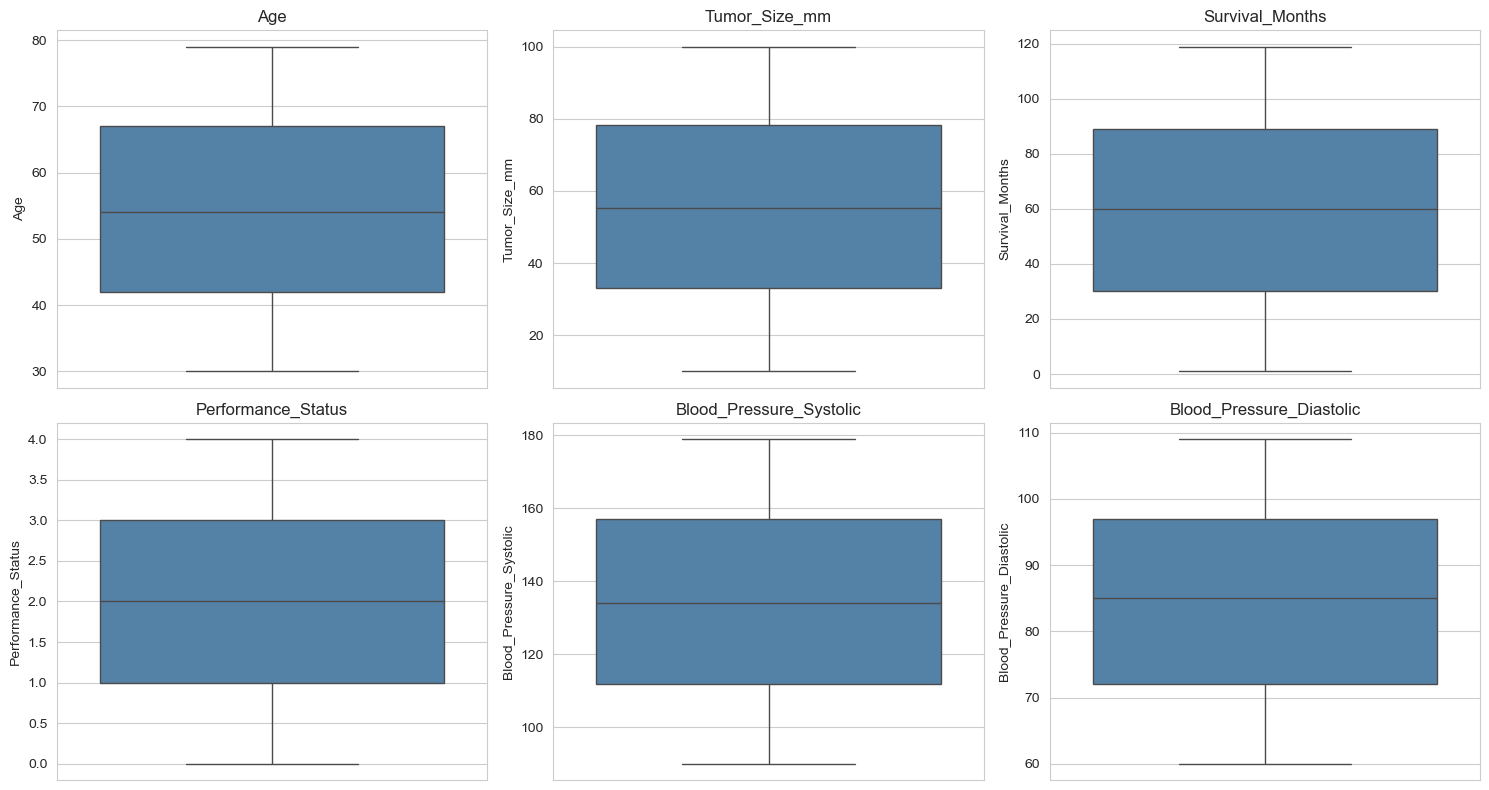

In [17]:
# Used Boxplots for visual confirmation
plot_cols = [c for c in numeric_columns][:6]  # show first 6 numeric columns
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), plot_cols):
    sns.boxplot(y=df[col], ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [18]:
# Creation of the Survival Outcome Target
df["Survival_Group"] = np.where(
    df["Survival_Months"] < 60,
    "Short-Term",
    "Long-Term"
)
print("Target class counts:")
print(df["Survival_Group"].value_counts())

Target class counts:
Survival_Group
Long-Term     11948
Short-Term    11710
Name: count, dtype: int64


In [19]:
# check percentages:
print("\nTarget class percentages:")
print(df["Survival_Group"].value_counts(normalize=True) * 100)


Target class percentages:
Survival_Group
Long-Term     50.503001
Short-Term    49.496999
Name: proportion, dtype: float64


# 6. Data cleaning Procedures

In [20]:
cleaned_df = df.copy()

In [21]:
# Remove patient identifier (not predictive)
cleaned_df = cleaned_df.drop(columns=["Patient_ID"])

In [22]:
# Remove Survival_Months (used to construct the target — avoids leakage)
cleaned_df = cleaned_df.drop(columns=["Survival_Months"])

In [23]:
cleaned_df.head()

,Age,Gender,Smoking_History,Tumor_Size_mm,Tumor_Location,Stage,Treatment,Ethnicity,Insurance_Type,Family_History,Comorbidity_Diabetes,Comorbidity_Hypertension,Comorbidity_Heart_Disease,Comorbidity_Chronic_Lung_Disease,Comorbidity_Kidney_Disease,Comorbidity_Autoimmune_Disease,Comorbidity_Other,Performance_Status,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Blood_Pressure_Pulse,Hemoglobin_Level,White_Blood_Cell_Count,Platelet_Count,Albumin_Level,Alkaline_Phosphatase_Level,Alanine_Aminotransferase_Level,Aspartate_Aminotransferase_Level,Creatinine_Level,LDH_Level,Calcium_Level,Phosphorus_Level,Glucose_Level,Potassium_Level,Sodium_Level,Smoking_Pack_Years,Survival_Group
0,68,Male,Current Smoker,81.678677,Lower Lobe,Stage III,Surgery,Hispanic,Medicare,No,Yes,Yes,Yes,No,Yes,Yes,Yes,3,161,99,92,13.538000,9.800707,321.735266,3.568383,49.310048,27.985571,46.801214,1.245849,239.240255,10.366307,3.547734,113.919243,4.968163,139.822861,17.006956,Short-Term
1,58,Male,Never Smoked,78.448272,Lower Lobe,Stage I,Radiation Therapy,Caucasian,Private,Yes,Yes,Yes,No,No,Yes,Yes,No,4,101,91,93,16.800312,4.378428,251.581538,3.699357,111.421632,30.120956,39.711531,1.463231,233.515237,10.081731,2.945020,101.321578,3.896795,135.449361,93.270893,Long-Term
2,44,Male,Former Smoker,67.714305,Lower Lobe,Stage I,Chemotherapy,African American,Other,Yes,No,No,No,Yes,Yes,No,No,0,109,74,81,14.473493,6.157792,393.456532,4.708385,76.648006,5.882418,32.640602,0.630109,169.037460,8.660892,4.637399,78.214177,4.369050,143.377155,70.348376,Long-Term
3,72,Male,Current Smoker,70.806008,Lower Lobe,Stage III,Chemotherapy,African American,Medicare,Yes,Yes,No,Yes,No,Yes,Yes,No,1,103,85,68,17.442063,6.259383,275.177898,4.727672,81.952486,38.908154,44.319393,0.594342,213.967590,8.832669,3.617098,127.895361,4.348474,138.586005,19.828128,Long-Term
4,37,Female,Never Smoked,87.272433,Lower Lobe,Stage IV,Radiation Therapy,Asian,Medicaid,No,Yes,Yes,Yes,No,Yes,No,No,0,165,69,99,13.545171,5.203516,381.705572,4.605604,107.513423,26.344877,15.746906,1.478239,118.187543,9.247609,4.773255,148.801185,3.671976,141.230724,81.047456,Long-Term


In [24]:
cleaned_df.shape

(23658, 37)

In [25]:
# Preparing Features and Target
X = cleaned_df.drop(columns=["Survival_Group"])
y = cleaned_df["Survival_Group"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (23658, 36)
Target shape: (23658,)


In [26]:
print("\nTarget value counts:")
print(y.value_counts())


Target value counts:
Survival_Group
Long-Term     11948
Short-Term    11710
Name: count, dtype: int64


In [27]:
# Identify categorical and numerical variables
categorical_features = X.select_dtypes(include="object").columns.tolist()
print("Categorical features:")
print(categorical_features)

Categorical features:
['Gender', 'Smoking_History', 'Tumor_Location', 'Stage', 'Treatment', 'Ethnicity', 'Insurance_Type', 'Family_History', 'Comorbidity_Diabetes', 'Comorbidity_Hypertension', 'Comorbidity_Heart_Disease', 'Comorbidity_Chronic_Lung_Disease', 'Comorbidity_Kidney_Disease', 'Comorbidity_Autoimmune_Disease', 'Comorbidity_Other']


In [28]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
print("\nNumerical features:")
print(numeric_features)


Numerical features:
['Age', 'Tumor_Size_mm', 'Performance_Status', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Blood_Pressure_Pulse', 'Hemoglobin_Level', 'White_Blood_Cell_Count', 'Platelet_Count', 'Albumin_Level', 'Alkaline_Phosphatase_Level', 'Alanine_Aminotransferase_Level', 'Aspartate_Aminotransferase_Level', 'Creatinine_Level', 'LDH_Level', 'Calcium_Level', 'Phosphorus_Level', 'Glucose_Level', 'Potassium_Level', 'Sodium_Level', 'Smoking_Pack_Years']


# Train/Test Split

The data is split **before** encoding and scaling to prevent information from the test set from leaking into the preprocessing pipeline. The split is
stratified to preserve the class proportions between the training and testing sets.

In [29]:
#Train/Test Split (BEFORE encoding and scaling)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (18926, 36)
Testing set: (4732, 36)

Training target distribution:
Survival_Group
Long-Term     0.50502
Short-Term    0.49498
Name: proportion, dtype: float64

Testing target distribution:
Survival_Group
Long-Term     0.505072
Short-Term    0.494928
Name: proportion, dtype: float64


# 7. Feature encoding methods

Categorical predictor variables are converted into numerical indicator variables using **one-hot encoding** (`pd.get_dummies`). One-hot encoding is
performed separately on the training and testing sets, and the test set is then aligned to the training columns. This prevents differences in category
columns between the two datasets.

`drop_first=True` is used to avoid perfect multicollinearity (dummy variable trap) in linear models.

In [30]:
# One-hot encode the training set
X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)
print("X_train_encoded shape:", X_train_encoded.shape)

X_train_encoded shape: (18926, 47)


In [31]:
# One-hot encode the test set
X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)
print("X_test_encoded shape: ", X_test_encoded.shape)

X_test_encoded shape:  (4732, 47)


In [32]:
# Align test columns to match training columns exactly
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)
print("Columns match:", list(X_train_encoded.columns) == list(X_test_encoded.columns))

Columns match: True


In [33]:
print("\nData type counts after encoding:")
print(X_train_encoded.dtypes.value_counts())


Data type counts after encoding:
int64      31
float64    16
Name: count, dtype: int64


# 8. Feature scaling

Numerical predictor variables are standardized using **StandardScaler**, which transforms each variable to have approximately zero mean and unit
variance.

The scaler is fitted on the **training data only**, then applied to both the training and testing sets. This is the correct approach for avoiding
information leakage during scaling.

In [34]:
# Feature Scaling (fit on train, apply to test)
scaler = StandardScaler()

X_train_scaled = X_train_encoded.copy()
X_test_scaled  = X_test_encoded.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(
    X_train_encoded[numeric_features]
)

X_test_scaled[numeric_features] = scaler.transform(
    X_test_encoded[numeric_features]
)

In [35]:
# Verify Scaling
print("=" * 60)
print("TRAINING SET — SCALED NUMERICAL FEATURES")
print("=" * 60)
print(X_train_scaled[numeric_features].describe().T)

TRAINING SET — SCALED NUMERICAL FEATURES
                                    count          mean       std       min  \
Age                               18926.0 -6.382345e-17  1.000026 -1.702070   
Tumor_Size_mm                     18926.0  1.475448e-16  1.000026 -1.748317   
Performance_Status                18926.0 -3.078543e-17  1.000026 -1.418353   
Blood_Pressure_Systolic           18926.0  4.503308e-16  1.000026 -1.700315   
Blood_Pressure_Diastolic          18926.0  4.610306e-16  1.000026 -1.692499   
Blood_Pressure_Pulse              18926.0  6.006913e-18  1.000026 -1.702318   
Hemoglobin_Level                  18926.0 -6.862898e-16  1.000026 -1.745200   
White_Blood_Cell_Count            18926.0  2.357713e-16  1.000026 -1.726557   
Platelet_Count                    18926.0 -2.245084e-16  1.000026 -1.722578   
Albumin_Level                     18926.0 -8.758830e-16  1.000026 -1.724374   
Alkaline_Phosphatase_Level        18926.0  7.193278e-16  1.000026 -1.728055   
Alanine_Ami

In [36]:
print("\nMeans (should be ~0):")
print(X_train_scaled[numeric_features].mean().round(3))


Means (should be ~0):
Age                                -0.0
Tumor_Size_mm                       0.0
Performance_Status                 -0.0
Blood_Pressure_Systolic             0.0
Blood_Pressure_Diastolic            0.0
Blood_Pressure_Pulse                0.0
Hemoglobin_Level                   -0.0
White_Blood_Cell_Count              0.0
Platelet_Count                     -0.0
Albumin_Level                      -0.0
Alkaline_Phosphatase_Level          0.0
Alanine_Aminotransferase_Level      0.0
Aspartate_Aminotransferase_Level   -0.0
Creatinine_Level                    0.0
LDH_Level                          -0.0
Calcium_Level                       0.0
Phosphorus_Level                   -0.0
Glucose_Level                       0.0
Potassium_Level                    -0.0
Sodium_Level                        0.0
Smoking_Pack_Years                 -0.0
dtype: float64


In [37]:
print("\nStandard deviations (should be ~1):")
print(X_train_scaled[numeric_features].std().round(3))


Standard deviations (should be ~1):
Age                                 1.0
Tumor_Size_mm                       1.0
Performance_Status                  1.0
Blood_Pressure_Systolic             1.0
Blood_Pressure_Diastolic            1.0
Blood_Pressure_Pulse                1.0
Hemoglobin_Level                    1.0
White_Blood_Cell_Count              1.0
Platelet_Count                      1.0
Albumin_Level                       1.0
Alkaline_Phosphatase_Level          1.0
Alanine_Aminotransferase_Level      1.0
Aspartate_Aminotransferase_Level    1.0
Creatinine_Level                    1.0
LDH_Level                           1.0
Calcium_Level                       1.0
Phosphorus_Level                    1.0
Glucose_Level                       1.0
Potassium_Level                     1.0
Sodium_Level                        1.0
Smoking_Pack_Years                  1.0
dtype: float64


# 9. Final cleaned dataset

The scaled training and testing features are combined with their respective target labels to produce the final modeling-ready datasets.

In [38]:
final_train = X_train_scaled.copy()
final_train["Survival_Group"] = y_train.values

final_test = X_test_scaled.copy()
final_test["Survival_Group"] = y_test.values

print("final_train shape:", final_train.shape)
print("final_test shape: ", final_test.shape)

final_train.head()

final_train shape: (18926, 48)
final_test shape:  (4732, 48)


,Age,Tumor_Size_mm,Performance_Status,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Blood_Pressure_Pulse,Hemoglobin_Level,White_Blood_Cell_Count,Platelet_Count,Albumin_Level,Alkaline_Phosphatase_Level,Alanine_Aminotransferase_Level,Aspartate_Aminotransferase_Level,Creatinine_Level,LDH_Level,Calcium_Level,Phosphorus_Level,Glucose_Level,Potassium_Level,Sodium_Level,Smoking_Pack_Years,Gender_Male,Smoking_History_Former Smoker,Smoking_History_Never Smoked,Tumor_Location_Middle Lobe,Tumor_Location_Upper Lobe,Stage_Stage II,Stage_Stage III,Stage_Stage IV,Treatment_Radiation Therapy,Treatment_Surgery,Treatment_Targeted Therapy,Ethnicity_Asian,Ethnicity_Caucasian,Ethnicity_Hispanic,Ethnicity_Other,Insurance_Type_Medicare,Insurance_Type_Other,Insurance_Type_Private,Family_History_Yes,Comorbidity_Diabetes_Yes,Comorbidity_Hypertension_Yes,Comorbidity_Heart_Disease_Yes,Comorbidity_Chronic_Lung_Disease_Yes,Comorbidity_Kidney_Disease_Yes,Comorbidity_Autoimmune_Disease_Yes,Comorbidity_Other_Yes,Survival_Group
486,-0.240912,-0.966507,-1.418353,1.100753,-0.441704,-1.702318,0.695594,-1.703922,-0.562074,-0.457330,0.980722,0.359598,0.693141,0.069466,-0.392759,-1.686832,-0.191506,0.204267,0.770297,-0.623400,-0.613784,0,1,0,0,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0,0,1,1,1,0,0,0,Short-Term
17590,-0.519228,-1.530267,0.703403,1.676315,-1.414545,1.163996,1.286170,-1.387466,-1.022042,1.233442,-1.487301,1.250852,-0.585278,-1.497487,-1.550417,0.259474,-1.468778,1.626324,0.369756,1.653478,-0.625462,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,1,1,1,1,1,0,Long-Term
8398,1.150666,0.111651,0.703403,-1.470091,0.322671,-0.920596,-0.392739,-0.775876,-1.234565,0.943067,-0.702790,-0.633217,0.750307,-1.301223,-0.229870,1.620395,0.116335,0.919554,-1.564518,-0.079160,-1.438153,0,0,1,0,1,0,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,1,1,0,0,0,Long-Term
22487,0.872351,0.450327,-0.711101,-0.165483,0.044716,-0.138874,0.385988,0.284477,1.286436,0.173335,1.190721,-0.081272,-0.340218,1.572317,1.248208,-0.229720,-0.453343,0.924409,0.865788,-0.699649,1.522355,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,1,0,1,1,0,1,1,Long-Term
7258,1.011508,1.553732,-1.418353,1.254236,1.087046,-0.399448,0.844230,0.275741,-0.242683,-0.741106,-0.438304,-0.704590,0.696201,-0.569590,0.406912,-1.363188,0.415458,0.807401,-1.057875,1.005403,-1.330827,0,0,1,1,0,1,0,0,0,0,1,0,1,0,0,0,1,0,1,1,0,1,1,1,0,1,Long-Term


In [39]:
# Final quality check
print("Missing values in training data:")
print(final_train.isnull().sum().sum())
print("\nTraining target distribution:")
print(final_train["Survival_Group"].value_counts())

Missing values in training data:
0

Training target distribution:
Survival_Group
Long-Term     9558
Short-Term    9368
Name: count, dtype: int64


In [40]:
print("\nMissing values in testing data:")
print(final_test.isnull().sum().sum())
print("\nTesting target distribution:")
print(final_test["Survival_Group"].value_counts())


Missing values in testing data:
0

Testing target distribution:
Survival_Group
Long-Term     2390
Short-Term    2342
Name: count, dtype: int64


# Save the cleaned data

The file lung_cancer_cleaned.csv contains the fully cleaned and encoded dataset with the target variable `Survival_Group`. Numerical features are
not scaled in this file. Scaling is model-specific and is applied within the modeling notebook after the train/test split, to prevent information
leakage from the test set into the training pipeline.

The train/test split is deterministic (random_state=42), so the exact train and test partitions used in this project can be reproduced from the
cleaned file at any time.

In [41]:
# Combine encoded train + test back into a single cleaned dataset
X_encoded_full = pd.concat([X_train_encoded, X_test_encoded], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)

final_cleaned = X_encoded_full.copy()
final_cleaned["Survival_Group"] = y_full.values

In [42]:
# Save
final_cleaned.to_csv("../data/lung_cancer_cleaned.csv", index=False)

print("Cleaned dataset saved to: ../data/lung_cancer_cleaned.csv")
print("Shape:", final_cleaned.shape)
print("Columns:", final_cleaned.columns.tolist())

Cleaned dataset saved to: ../data/lung_cancer_cleaned.csv
Shape: (23658, 48)
Columns: ['Age', 'Tumor_Size_mm', 'Performance_Status', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Blood_Pressure_Pulse', 'Hemoglobin_Level', 'White_Blood_Cell_Count', 'Platelet_Count', 'Albumin_Level', 'Alkaline_Phosphatase_Level', 'Alanine_Aminotransferase_Level', 'Aspartate_Aminotransferase_Level', 'Creatinine_Level', 'LDH_Level', 'Calcium_Level', 'Phosphorus_Level', 'Glucose_Level', 'Potassium_Level', 'Sodium_Level', 'Smoking_Pack_Years', 'Gender_Male', 'Smoking_History_Former Smoker', 'Smoking_History_Never Smoked', 'Tumor_Location_Middle Lobe', 'Tumor_Location_Upper Lobe', 'Stage_Stage II', 'Stage_Stage III', 'Stage_Stage IV', 'Treatment_Radiation Therapy', 'Treatment_Surgery', 'Treatment_Targeted Therapy', 'Ethnicity_Asian', 'Ethnicity_Caucasian', 'Ethnicity_Hispanic', 'Ethnicity_Other', 'Insurance_Type_Medicare', 'Insurance_Type_Other', 'Insurance_Type_Private', 'Family_History_Yes', 'Como

# 10. Final preprocessing summary

The dataset was first reviewed to understand its structure and identify any potential data quality issues. This included checking the data types, duplicate records, missing values, and unusual observations. The dataset contained **23,658 patient records** and **38 original variables**. No missing values or duplicate records were found.

The numerical variables were examined using descriptive statistics and the interquartile range (IQR) method to check for potential outliers. Using the
1.5 × IQR rule, no observations were identified as statistical outliers. Therefore, no records were removed based on outlier detection.

The `Survival_Months` variable from the original dataset was used to create the binary survival outcome for this project. Patients who survived fewer than 60 months were classified as short-term survivors, while those who survived 60 months or longer were classified as long-term survivors. This classification resulted in **11,710 short-term** survival cases and **11,948 long-term** survival cases.

Before building the models, Patient_ID was removed because it is simply an identifier and does not provide useful information for predicting survival
outcomes. The Survival_Months variable was also removed from the predictors because it was directly used to create the target variable. Keeping it as a predictor would result in target leakage and could give the models information that would not be available when making predictions for new patients.

The data was split into training (80%) and testing (20%) sets before encoding and scaling, using stratified sampling to preserve class proportions.
Categorical variables were converted into numerical features using one-hot encoding, with the encoder fitted on the training set and applied to the test set. Numerical variables were standardized using StandardScaler, again fitted only on the training data and applied to both sets. This approach prevents information from the test set from influencing the preprocessing pipeline.

After these preprocessing steps, the dataset is ready for the next stage of the project: training and evaluating machine learning models to predict individual patient survival outcomes.
